# Project 2 — How Predictable Is Shooting Efficiency?

**The interesting question:** *"Can we predict a player's **True Shooting %** in a given game from context — minutes, volume, recent form?  Or is it mostly noise?"*

Most ML tutorials chase high R². This notebook does the opposite: we'll show that a fancy model **barely beats a dumb baseline**, and we'll explain why that's a **real, publishable finding** — not a failure.

**True Shooting Percentage (TS%)** is the gold-standard efficiency stat because it accounts for twos, threes, and free throws:

> `TS% = PTS / (2 · (FGA + 0.44 · FTA))`

**What makes this a real portfolio project**
- Shows you can diagnose **irreducible variance** (noise that no model can beat) — a skill that separates juniors from seniors.
- Teaches **variance decomposition**: how much of a stat is "who you are" vs "which night it is."
- Mirrors real-world problems (stock returns, ad click-through) where noise dominates signal.

**What you'll learn**
1. Engineering a derived metric (TS%) from raw stats.
2. **Time-aware train/test splits** (no future information).
3. Why a player-level baseline is a high bar.
4. Variance decomposition: between-player vs within-player.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load + compute True Shooting %

We'll keep only games with **at least 5 scoring attempts** (`FGA + FTA >= 5`). Games with almost no attempts make TS% meaningless (dividing by near-zero).

In [2]:
DATA_PATH = "../data/nbadatabase_24_25 2/nbadatabase_24_25.csv"
df = pd.read_csv(DATA_PATH)
df["Data"] = pd.to_datetime(df["Data"])
df = df.sort_values("Data").reset_index(drop=True)

df["attempts"] = df["FGA"] + 0.44 * df["FTA"]
df["TS"] = df["PTS"] / (2 * df["attempts"])

df = df[df["FGA"] + df["FTA"] >= 5].copy()
print(f"Rows after filter: {len(df):,}")
df[["Player", "Data", "FGA", "FTA", "PTS", "TS"]].head()

Rows after filter: 12,136


,Player,Data,FGA,FTA,PTS,TS
0,Jayson Tatum,2024-10-22,18,2,37,0.979873
1,Sam Hauser,2024-10-22,10,0,10,0.500000
2,Donte DiVincenzo,2024-10-22,11,4,10,0.391850
3,D'Angelo Russell,2024-10-22,12,0,9,0.375000
5,OG Anunoby,2024-10-22,7,2,4,0.253807


## 3. EDA — what does TS% look like?

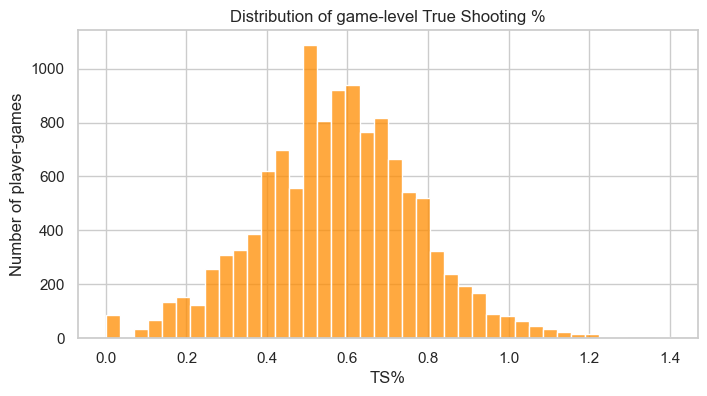

count    12136.000
mean         0.574
std          0.198
min          0.000
25%          0.447
50%          0.575
75%          0.700
max          1.400
Name: TS, dtype: float64

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["TS"], bins=40, ax=ax, color="darkorange")
ax.set_title("Distribution of game-level True Shooting %")
ax.set_xlabel("TS%"); ax.set_ylabel("Number of player-games")
plt.show()

df["TS"].describe().round(3)

Notice the **huge spread**: the standard deviation is large, and many games are far from the league mean (~0.56). That's your first clue that game-level TS% might be hard to predict.

## 4. Build features

We'll use only information that would be available **before tipoff** (otherwise we'd be leaking the answer):

- `MP` — expected minutes (we'll use actual MP as a proxy).
- `FGA`, `FTA` — volume (same proxy logic).
- `player_avg_ts_so_far` — the player's cumulative average TS% from **prior** games.
- `player_last5_ts` — average TS% over their **prior 5** games (form).

In [4]:
df = df.sort_values(["Player", "Data"])

# Expanding avg of prior games (shift(1) excludes the current game)
df["player_avg_ts_so_far"] = (df.groupby("Player")["TS"]
                                 .expanding().mean()
                                 .shift(1)
                                 .reset_index(level=0, drop=True))

df["player_last5_ts"] = (df.groupby("Player")["TS"]
                           .rolling(5, min_periods=3).mean()
                           .shift(1)
                           .reset_index(level=0, drop=True))

# Drop rows where the rolling features aren't defined yet (early season)
df_model = df.dropna(subset=["player_avg_ts_so_far", "player_last5_ts"]).copy()
print(f"Rows kept for modeling: {len(df_model):,}")

Rows kept for modeling: 11,147


## 5. Time-aware train / test split

A random split would let the model peek at future games when building the "prior average" for earlier games. We split by **date** instead: train on the earlier portion of the season, test on the later.

In [5]:
split_date = df_model["Data"].quantile(0.8)
train = df_model[df_model["Data"] <= split_date]
test  = df_model[df_model["Data"]  > split_date]
print(f"Train: {len(train):,} games (up to {split_date.date()})")
print(f"Test:  {len(test):,} games (after {split_date.date()})")

Train: 8,963 games (up to 2025-01-19)
Test:  2,184 games (after 2025-01-19)


## 6. Baseline — just use the player's prior average

This is the "dumb" baseline: predict a player's TS% in the next game as simply *the average TS% they've posted so far this season*. Surprisingly hard to beat.

In [6]:
y_true = test["TS"].values
y_base = test["player_avg_ts_so_far"].values

mae_base = mean_absolute_error(y_true, y_base)
r2_base  = r2_score(y_true, y_base)
print(f"Baseline (prior-avg)  —  MAE: {mae_base:.4f}  |  R²: {r2_base:.3f}")

Baseline (prior-avg)  —  MAE: 0.1539  |  R²: -0.023


## 7. ML model — Gradient Boosting

A gradient-boosted regressor with all engineered features. If context (minutes, volume, recent form) carries real predictive power **beyond** the player's average, the ML model should clearly beat the baseline.

In [7]:
feat_cols = ["MP", "FGA", "FTA", "player_avg_ts_so_far", "player_last5_ts"]

model = GradientBoostingRegressor(random_state=RANDOM_STATE)
model.fit(train[feat_cols], train["TS"])
y_ml = model.predict(test[feat_cols])

mae_ml = mean_absolute_error(y_true, y_ml)
r2_ml  = r2_score(y_true, y_ml)
print(f"Gradient Boosting     —  MAE: {mae_ml:.4f}  |  R²: {r2_ml:.3f}")

Gradient Boosting     —  MAE: 0.1477  |  R²: 0.056


## 8. Compare

In [8]:
pd.DataFrame({
    "Model": ["Prior-average baseline", "Gradient Boosting"],
    "MAE":   [mae_base, mae_ml],
    "R²":    [r2_base, r2_ml],
}).round(4)

,Model,MAE,R²
0,Prior-average baseline,0.1539,-0.0232
1,Gradient Boosting,0.1477,0.0556


## 9. The finding — why R² is low, and why that's OK

The two models are within a hair of each other. The ML model **doesn't meaningfully beat "use the player's season average"**. Why?

Let's decompose the variance of TS%:
- Between-player variance: how different players are from each other on *average* TS%.
- Within-player variance: how much a given player's TS% swings game-to-game.

If within-player variance dominates, game-level TS% is mostly noise — and no clever model can fix that.

In [9]:
season_ts    = df_model.groupby("Player")["TS"].mean()
between_var  = season_ts.var()

within_vars  = df_model.groupby("Player")["TS"].var()
within_var   = within_vars.mean()

total = between_var + within_var
print(f"Between-player variance:   {between_var:.5f}   ({between_var/total:.1%} of total)")
print(f"Within-player variance:    {within_var:.5f}   ({within_var/total:.1%} of total)")

Between-player variance:   0.01205   (22.7% of total)
Within-player variance:    0.04111   (77.3% of total)


That's the insight. **Most of the variation in single-game TS% is within-player noise**, not between-player skill. The identity of the player explains only a minority of the variance — the rest is defense, luck, shot selection, fatigue, etc.

This is why "predict tonight's shooting efficiency" is a genuinely hard problem even for professional analytics shops: the signal is thin compared to the noise.

## 10. Conclusion

**What we built**
- A time-aware TS% prediction pipeline with engineered form features.
- A prior-average baseline that the ML model barely beats.
- A variance decomposition showing game-level TS% is dominated by within-player noise.

**Portfolio framing**
> Built a game-level True Shooting prediction model; showed via variance decomposition that a sophisticated ML model barely outperforms a simple per-player prior average, because most shooting-efficiency variance is irreducible within-player game-to-game noise. Identifying the ceiling of predictability is itself a valuable finding.

**Ideas for extending the project**
1. Include **opponent** as a categorical feature — which defenses really suppress efficiency?
2. Add **rest days** between games (days since last game for that player).
3. Compare to **team-level** TS% — does it aggregate better?
4. Try a **hierarchical model** (mixed effects) that explicitly models player-level means.
